# Notebook 02 — Qwen2.5-VL Zero-shot 베이스라인 평가

## 목표
파인튜닝 **전** Qwen2.5-VL 7B의 불량 분류 성능을 측정한다.  
이 수치가 Notebook 04에서 파인튜닝 후와 비교되는 **베이스라인**이 된다.

## 평가 지표
| 지표 | 설명 |
|------|------|
| **Type Accuracy** | 불량 유형 정확히 맞춘 비율 (핵심) |
| **Severity Accuracy** | 심각도 정확히 맞춘 비율 |
| **JSON Parse Rate** | 답변이 유효한 JSON인 비율 |
| **Per-class F1** | 클래스별 F1 Score |

In [1]:
%pip install -q matplotlib numpy pandas Pillow scikit-learn seaborn tqdm transformers accelerate bitsandbytes

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

import json, re, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

_cwd = Path.cwd()
ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
DATA_PROCESSED = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "data" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEFECT_CLASSES = [
    "crazing", "inclusion", "patches",
    "pitted_surface", "rolled-in_scale", "scratches"
]

assert (DATA_PROCESSED / "test.json").exists(), (
    f"test.json 없음: {DATA_PROCESSED / 'test.json'}\n"
    "먼저 01_dataset.ipynb를 실행해 데이터를 준비하세요."
)

with open(DATA_PROCESSED / "test.json", encoding="utf-8") as f:
    test_data = json.load(f)

print(f"Test set: {len(test_data)}개")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
if torch.cuda.is_available():
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Test set: 270개
GPU: NVIDIA GeForce RTX 4080 SUPER
VRAM: 17.2 GB


## 1. Qwen2.5-VL 모델 로드 (4-bit 양자화)

In [3]:
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)

MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"

# 4-bit 양자화 설정 (VRAM 절약 — 7B 모델을 약 4GB로 압축)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f"모델 로드 중: {MODEL_ID}")
print("4-bit 양자화 적용 (NF4 + double quant)")

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)
processor = AutoProcessor.from_pretrained(MODEL_ID)

model.eval()
print(f"모델 로드 완료")
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

c:\Users\apple\anaconda3\envs\anomaly_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


모델 로드 중: Qwen/Qwen2.5-VL-7B-Instruct
4-bit 양자화 적용 (NF4 + double quant)


Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\apple\anaconda3\envs\anomaly_env\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\apple\anaconda3\envs\anomaly_env\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\apple\anaconda3\envs\anomaly_env\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 6: invalid start byte
Loading weights: 100%|██████████| 729/729 [00:11<00:00, 60.87it/s] 


모델 로드 완료
파라미터 수: 4.69B


## 2. 추론 함수 및 파싱 유틸리티

In [4]:
SYSTEM_PROMPT = (
    "당신은 금속 제품 표면 불량을 분석하는 전문 AI입니다. "
    "주어진 이미지를 분석하여 불량 유형을 정확히 판단하고 "
    "반드시 JSON 형식으로만 답변하세요."
)

INFERENCE_PROMPT = (
    "이 금속 표면 이미지를 분석하고 불량 정보를 JSON 형식으로 출력해줘.\n"
    "불량 유형은 반드시 다음 중 하나여야 해: "
    "crazing, inclusion, patches, pitted_surface, rolled-in_scale, scratches\n"
    '출력 형식: {"type": "...", "type_ko": "...", "severity": "low|medium|high", "description": "..."}'
)


def resolve_image(path: str) -> Path:
    """상대 경로는 ROOT 기준으로 절대 경로로 변환"""
    p = Path(path)
    return (ROOT / p) if not p.is_absolute() else p


def infer_single(image_path: str) -> tuple[str, float]:
    """이미지 1장 추론 → (raw_output, elapsed_sec)"""
    img = Image.open(resolve_image(image_path)).convert("RGB")
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": [
                {"type": "image", "image": img},
                {"type": "text",  "text": INFERENCE_PROMPT},
            ],
        },
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(
        text=[text],
        images=[img],
        return_tensors="pt",
        padding=True,
    ).to(model.device)

    t0 = time.time()
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
            temperature=None,
            top_p=None,
        )
    elapsed = time.time() - t0

    generated = output_ids[:, inputs["input_ids"].shape[1]:]
    raw = processor.batch_decode(generated, skip_special_tokens=True)[0].strip()
    return raw, elapsed


def parse_output(raw: str) -> dict | None:
    """raw 텍스트에서 JSON 추출"""
    raw = re.sub(r"```json\s*", "", raw)
    raw = re.sub(r"```\s*", "", raw)
    match = re.search(r"\{.*\}", raw, re.DOTALL)
    if not match:
        return None
    try:
        return json.loads(match.group())
    except json.JSONDecodeError:
        return None


# 동작 테스트
sample_record = test_data[0]
raw, t = infer_single(sample_record["image"])
parsed = parse_output(raw)
gt = json.loads(sample_record["conversations"][1]["content"])
print(f"추론 시간: {t:.2f}s")
print(f"정답    : {gt['type']}")
print(f"예측    : {parsed['type'] if parsed else 'PARSE_ERROR'}")
print(f"Raw     : {raw[:200]}")

추론 시간: 4.32s
정답    : patches
예측    : patches
Raw     : ```json
{
  "type": "patches",
  "type_ko": "점상",
  "severity": "medium",
  "description": "금속 표면에 작은 점상이 보입니다."
}
```


## 3. 전체 Test Set 평가

In [5]:
CHECKPOINT_PATH = RESULTS_DIR / "baseline_results_partial.csv"
CHECKPOINT_EVERY = 50

# 이어서 실행 가능: 중간 저장본이 있으면 로드
done_ids: set[str] = set()
results: list[dict] = []
if CHECKPOINT_PATH.exists():
    prev_df = pd.read_csv(CHECKPOINT_PATH)
    results = prev_df.to_dict("records")
    done_ids = set(prev_df["id"])
    print(f"체크포인트 로드: {len(done_ids)}개 완료")

remaining = [r for r in test_data if r["id"] not in done_ids]
print(f"남은 샘플: {len(remaining)}개")

for i, record in enumerate(tqdm(remaining, desc="Zero-shot 추론")):
    gt = json.loads(record["conversations"][1]["content"])
    raw, elapsed = infer_single(record["image"])
    parsed = parse_output(raw)

    pred_type = None
    pred_severity = None
    if parsed:
        pred_type = parsed.get("type", "").strip().lower()
        pred_severity = parsed.get("severity", "").strip().lower()
        if pred_type not in DEFECT_CLASSES:
            pred_type = None

    results.append({
        "id": record["id"],
        "image": record["image"],
        "gt_type": gt["type"],
        "gt_severity": gt["severity"],
        "pred_type": pred_type,
        "pred_severity": pred_severity,
        "json_ok": parsed is not None,
        "elapsed": elapsed,
        "raw": raw,
    })

    if (i + 1) % CHECKPOINT_EVERY == 0:
        pd.DataFrame(results).to_csv(CHECKPOINT_PATH, index=False)

results_df = pd.DataFrame(results)

json_parse_rate = results_df["json_ok"].mean()
type_acc = (results_df["pred_type"] == results_df["gt_type"]).mean()
sev_acc = (results_df["pred_severity"] == results_df["gt_severity"]).mean()
avg_time = results_df["elapsed"].mean()

print("=" * 45)
print("  Zero-shot 베이스라인 결과")
print("=" * 45)
print(f"  JSON Parse Rate  : {json_parse_rate*100:.1f}%")
print(f"  Type Accuracy    : {type_acc*100:.1f}%")
print(f"  Severity Accuracy: {sev_acc*100:.1f}%")
print(f"  Avg Latency      : {avg_time:.2f}s/image")
print("=" * 45)

results_df.to_csv(RESULTS_DIR / "baseline_results.csv", index=False)
CHECKPOINT_PATH.unlink(missing_ok=True)
print("저장: data/results/baseline_results.csv")

체크포인트 로드: 50개 완료
남은 샘플: 220개


Zero-shot 추론: 100%|██████████| 220/220 [12:12<00:00,  3.33s/it]

  Zero-shot 베이스라인 결과
  JSON Parse Rate  : 100.0%
  Type Accuracy    : 33.7%
  Severity Accuracy: 27.8%
  Avg Latency      : 3.37s/image
저장: data/results/baseline_results.csv


## 4. 클래스별 성능 분석 & 혼동 행렬

클래스별 성능 (유효 예측 기준):
                 precision    recall  f1-score   support

        crazing       0.00      0.00      0.00        45
      inclusion       0.00      0.00      0.00        45
        patches       0.21      0.89      0.34        45
 pitted_surface       0.64      0.51      0.57        45
rolled-in_scale       0.00      0.00      0.00        45
      scratches       0.72      0.62      0.67        45

       accuracy                           0.34       270
      macro avg       0.26      0.34      0.26       270
   weighted avg       0.26      0.34      0.26       270


클래스별 JSON Parse Rate:
gt_type
crazing            100.0
inclusion          100.0
patches            100.0
pitted_surface     100.0
rolled-in_scale    100.0
scratches          100.0


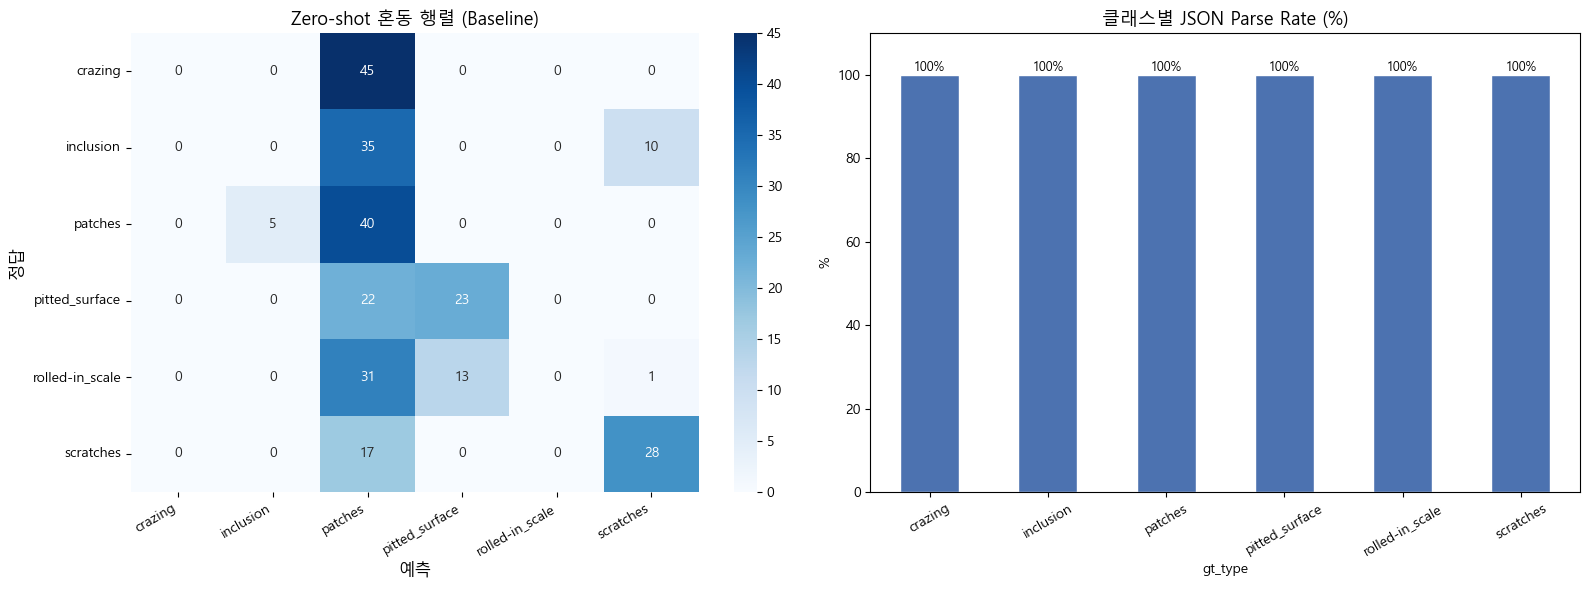

저장: data/results/baseline_confusion_matrix.png


In [6]:
valid_df = results_df.dropna(subset=["pred_type"])

# Classification Report
print("클래스별 성능 (유효 예측 기준):")
print(classification_report(
    valid_df["gt_type"], valid_df["pred_type"],
    labels=DEFECT_CLASSES, zero_division=0
))

# 클래스별 JSON 파싱 성공률
parse_by_class = results_df.groupby("gt_type")["json_ok"].mean() * 100
print("\n클래스별 JSON Parse Rate:")
print(parse_by_class.round(1).to_string())

# 혼동 행렬 + Parse Rate 나란히
cm = confusion_matrix(valid_df["gt_type"], valid_df["pred_type"], labels=DEFECT_CLASSES)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=DEFECT_CLASSES, yticklabels=DEFECT_CLASSES, ax=axes[0])
axes[0].set_xlabel("예측", fontsize=12)
axes[0].set_ylabel("정답", fontsize=12)
axes[0].set_title("Zero-shot 혼동 행렬 (Baseline)", fontsize=13)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

parse_by_class.reindex(DEFECT_CLASSES).plot(
    kind="bar", ax=axes[1], color="#4C72B0", edgecolor="white"
)
axes[1].set_title("클래스별 JSON Parse Rate (%)", fontsize=13)
axes[1].set_ylabel("%")
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(parse_by_class.reindex(DEFECT_CLASSES)):
    axes[1].text(i, v + 1, f"{v:.0f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장: data/results/baseline_confusion_matrix.png")

In [7]:
# 베이스라인 수치를 JSON으로 저장 (Notebook 04에서 비교용)
baseline_metrics = {
    "model": "Qwen2.5-VL-7B-Instruct (zero-shot, 4bit)",
    "json_parse_rate": round(float(json_parse_rate), 4),
    "type_accuracy": round(float(type_acc), 4),
    "severity_accuracy": round(float(sev_acc), 4),
    "avg_latency_sec": round(float(avg_time), 3),
    "n_test": len(test_data),
}
with open(RESULTS_DIR / "baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)

print("=" * 45)
print("  베이스라인 수치 저장 완료")
print("=" * 45)
for k, v in baseline_metrics.items():
    print(f"  {k:25s}: {v}")
print()
print("다음 단계: 03_finetune.ipynb")
print("  → QLoRA 파인튜닝 후 이 수치를 뛰어넘는 게 목표")

  베이스라인 수치 저장 완료
  model                    : Qwen2.5-VL-7B-Instruct (zero-shot, 4bit)
  json_parse_rate          : 1.0
  type_accuracy            : 0.337
  severity_accuracy        : 0.2778
  avg_latency_sec          : 3.375
  n_test                   : 270

다음 단계: 03_finetune.ipynb
  → QLoRA 파인튜닝 후 이 수치를 뛰어넘는 게 목표
